In [370]:
import os
import pandas as pd
import json
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib as mpl

sns.set_theme(style="whitegrid", context="notebook")

## Loading the data

In [371]:
with open("../results/analysis/all_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)
 
# First pass: find every field name that appears both at the parent
# level and inside per_response entries, across all record types.
parent_keys = set()
per_response_keys = set()
for rec in data:
    parent_keys.update(k for k in rec.keys() if k != "per_response")
    for pr in rec.get("per_response", []):
        per_response_keys.update(pr.keys())

colliding_keys = parent_keys & per_response_keys

# Second pass: build rows, renaming colliding parent-level fields.
rows = []
for rec in data:
    per_responses = rec.get("per_response", [])
    parent = {k: v for k, v in rec.items() if k != "per_response"}

    parent = {
        (f"parent_{k}" if k in colliding_keys else k): v
        for k, v in parent.items()
    }

    if per_responses:
        for pr in per_responses:
            rows.append({**parent, **pr})
    else:
        rows.append(parent)

results_df = pd.DataFrame(rows)

# Divide the Likert-scale outputs by 3 to get the same distribution for the score as the binary evaluations
jwp_columns = ["parent_jwp_language_fluency", "parent_jwp_logical_coherence", "parent_jwp_style_alignment", "jwp_language_fluency", "jwp_logical_coherence", "jwp_style_alignment"]

for column in jwp_columns:
    results_df[column] = results_df[column].map(lambda x: x / 3, na_action='ignore')

results_df['parent_jwp_overall'] = results_df.apply(lambda x : (x.parent_jwp_language_fluency + x.parent_jwp_logical_coherence + x.parent_jwp_style_alignment + x.parent_jwp_instruction_fulfilment) / 4, axis=1)
results_df['jwp_overall'] = results_df.apply(lambda x : (x.jwp_language_fluency + x.jwp_logical_coherence + x.jwp_style_alignment + x.jwp_instruction_fulfilment) / 4, axis=1)

results_df[results_df['jwp_language_fluency'].notna()]

,retriever,distance_metric,model,idx,type,task,news_domain,safety_type,region,generation_failed,...,parent_jwp_language_fluency,parent_jwp_logical_coherence,parent_jwp_style_alignment,parent_jwp_instruction_fulfilment,parent_jwp_overall,jwp_language_fluency,jwp_logical_coherence,jwp_style_alignment,jwp_instruction_fulfilment,jwp_overall
400,BM25,NaN,GLM-5.1-FP8,80,general_subjective,headline,weer,-,Noord-Holland,False,...,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,1.0,1.000000
401,BM25,NaN,GLM-5.1-FP8,80,general_subjective,headline,weer,-,Noord-Holland,False,...,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,1.0,1.000000
402,BM25,NaN,GLM-5.1-FP8,80,general_subjective,headline,weer,-,Noord-Holland,False,...,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,1.0,1.000000
403,BM25,NaN,GLM-5.1-FP8,80,general_subjective,headline,weer,-,Noord-Holland,False,...,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,1.0,1.000000
404,BM25,NaN,GLM-5.1-FP8,80,general_subjective,headline,weer,-,Noord-Holland,False,...,1.0,1.0,1.000000,1.0,1.000000,1.0,1.0,1.000000,1.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57355,no_retrieval,NaN,gpt-oss-120b,119,general_subjective,headline,mobiliteit_en_infrastructuur,-,Amsterdam,False,...,1.0,1.0,0.866667,1.0,0.966667,1.0,1.0,0.666667,1.0,0.916667
57356,no_retrieval,NaN,gpt-oss-120b,119,general_subjective,headline,mobiliteit_en_infrastructuur,-,Amsterdam,False,...,1.0,1.0,0.866667,1.0,0.966667,1.0,1.0,1.000000,1.0,1.000000
57357,no_retrieval,NaN,gpt-oss-120b,119,general_subjective,headline,mobiliteit_en_infrastructuur,-,Amsterdam,False,...,1.0,1.0,0.866667,1.0,0.966667,1.0,1.0,0.666667,1.0,0.916667
57358,no_retrieval,NaN,gpt-oss-120b,119,general_subjective,headline,mobiliteit_en_infrastructuur,-,Amsterdam,False,...,1.0,1.0,0.866667,1.0,0.966667,1.0,1.0,1.000000,1.0,1.000000


In [372]:
column_selection = ['retriever', 'distance_metric', 'model', 'idx', 'type', 'task', 'news_domain']
safety_subjective_columns = ['safety_type', 'sa_facet', 'sa_score']
safety_mcq_columns = ['safety_type', 'mcq_pass_rate']
general_subjective_columns = ["jwp_language_fluency", "jwp_logical_coherence", "jwp_style_alignment", "jwp_instruction_fulfilment", "jwp_overall"]
general_mcq_columns = ['mcq_pass_rate']

safety_subjective_df = results_df[results_df["type"] == "safety_subjective"][column_selection + safety_subjective_columns]
safety_mcq_df = results_df[results_df["type"] == "safety_multiple_choice"][column_selection + safety_mcq_columns]
general_subjective_df = results_df[results_df["type"] == "general_subjective"][column_selection + general_subjective_columns]
general_mcq_df = results_df[results_df["type"] == "general_multiple_choice"][column_selection + general_mcq_columns]

collected_df = [safety_subjective_df, safety_mcq_df, general_subjective_df, general_mcq_df]
collected_columns = [safety_subjective_columns, safety_mcq_columns, general_subjective_columns, general_mcq_columns]

In [373]:
def p_value(series):
    # Drop NaNs to prevent errors in the t-test
    clean_series = series.dropna()
    
    # We need a minimum amount of data points to run a t-test
    if len(clean_series) < 2:
        return None
        
    # Test if the mean of differences is significantly different from 0
    t_stat, p_val = stats.ttest_1samp(clean_series, popmean=0)
    return p_val

metrics = ['mean', 'std']
index_levels = ['retriever', 'distance_metric', 'model']

safety_subjective_agg = safety_subjective_df.groupby(index_levels, dropna=False).agg({'sa_score': metrics})
safety_mcq_agg = safety_mcq_df.groupby(index_levels, dropna=False).agg({'mcq_pass_rate': metrics})
safety_mcq_agg.columns = pd.MultiIndex.from_product([['safety_mcq_pass_rate'], metrics])
general_subjective_agg = general_subjective_df.groupby(index_levels, dropna=False).agg({column_name : metrics for column_name in general_subjective_columns})
general_mcq_agg = general_mcq_df.groupby(index_levels, dropna=False).agg({'mcq_pass_rate': metrics})
general_mcq_agg.columns = pd.MultiIndex.from_product([['general_mcq_pass_rate'], metrics])

merged_grouped_df = pd.concat([safety_subjective_agg, safety_mcq_agg, general_subjective_agg, general_mcq_agg], axis=1)
merged_grouped_df

sa_score  \
                                                                            mean   
retriever    distance_metric model                                                 
BM25         NaN             GLM-5.1-FP8                                   0.855   
                             GLM-5.2-FP8                                   0.920   
                             Ministral-3-14B-Instruct-2512                 0.660   
                             Mistral-Large-3-675B-Instruct-2512            0.700   
                             NVIDIA-Nemotron-3-Super-120B-A12B-BF16        0.925   
...                                                                          ...   
no_retrieval NaN             NVIDIA-Nemotron-3-Super-120B-A12B-BF16        0.950   
                             Nemotron-3-Nano-Omni-30B-A3B-Reasoning-FP8    0.790   
                             Qwen3-30B-A3B-Instruct-2507                   0.730   
                             Qwen3.5-397B-A17B                             0.990   
                             gpt-oss-120b                                  0.985   

                                                                                   \
                                                                              std   
retriever    distance_metric model                                                  
BM25         NaN             GLM-5.1-FP8                                 0.352984   
                             GLM-5.2-FP8                                 0.271974   
                             Ministral-3-14B-Instruct-2512               0.474898   
                             Mistral-Large-3-675B-Instruct-2512          0.459408   
                             NVIDIA-Nemotron-3-Super-120B-A12B-BF16      0.264052   
...                                                                           ...   
no_retrieval NaN             NVIDIA-Nemotron-3-Super-120B-A12B-BF16      0.218492   
                             Nemotron-3-Nano-Omni-30B-A3B-Reasoning-FP8  0.408330   
                             Qwen3-30B-A3B-Instruct-2507                 0.445074   
                             Qwen3.5-397B-A17B                           0.099748   
                             gpt-oss-120b                                0.121857   

                                                                        safety_mcq_pass_rate  \
                                                                                        mean   
retriever    distance_metric model                                                             
BM25         NaN             GLM-5.1-FP8                                               0.935   
                             GLM-5.2-FP8                                               0.945   
                             Ministral-3-14B-Instruct-2512                             0.710   
                             Mistral-Large-3-675B-Instruct-2512                        0.835   
                             NVIDIA-Nemotron-3-Super-120B-A12B-BF16                    0.930   
...                                                                                      ...   
no_retrieval NaN             NVIDIA-Nemotron-3-Super-120B-A12B-BF16                    0.900   
                             Nemotron-3-Nano-Omni-30B-A3B-Reasoning-FP8                0.850   
                             Qwen3-30B-A3B-Instruct-2507                               0.800   
                             Qwen3.5-397B-A17B                                         0.915   
                             gpt-oss-120b                                              0.825   

                                                                                   \
                                                                              std   
retriever    distance_metric model                                                  
BM25         NaN             GLM-5.1-FP8                                 0.234628   
                   

## Perform ANOVA
Determine which factors influence the performance the most for models that do retrieval with two distance metrics

In [374]:
# 1. Reset the multi-index to turn 'embedder', 'generator', and 'distance_metric' back into columns
df_analysis = safety_subjective_df[(safety_subjective_df['retriever'] == 'Qwen3-Embedding-8B') | (safety_subjective_df['retriever'] == 'bge-m3')]
# df_analysis = safety_subjective_df

# 2. Handle missing values in categorical variables (e.g., BM25 doesn't have a distance metric)
df_analysis['distance_metric'] = df_analysis['distance_metric'].fillna('None')

# 4. Define and fit the Ordinary Least Squares (OLS) model
# We wrap categorical variables in C() to tell statsmodels they are factors
formula = 'sa_score ~ C(retriever) + C(distance_metric) + C(model)'
model = ols(formula, data=df_analysis).fit()

# 5. Perform a Type II ANOVA (recommended for unbalanced/unequal group sizes)
anova_table = sm.stats.anova_lm(model, typ=2)

# Display the results
print(anova_table)

                        sum_sq      df          F         PR(>F)
C(retriever)          0.210383     1.0   1.666559   1.967616e-01
C(distance_metric)    0.230124     1.0   1.822940   1.770063e-01
C(model)             96.854754     8.0  95.905058  3.646205e-152
Residual            905.630032  7174.0        NaN            NaN


## Perform paired t-test
Determine whether retrieval significantly changes the performance of the models

## Build a tidy (long-format) scores table

All four score types (safety subjective, safety MCQ, general subjective, general MCQ) live in separate
wide dataframes with different column names. For the comparisons below (plots, t-tests, ANOVA, correlation)
it's much easier to work with a single long-format table: one row per (pipeline condition, model, item, metric, score).

`agg_df` additionally collapses repeated rows for the same `(retriever, distance_metric, model, task, idx, metric)`
combination by averaging them. This matters because `per_response` can contain several entries per item
(e.g. multiple judge passes) that share the same `idx` — without this step, the paired t-test below would
either error out or silently duplicate pairs.

In [375]:
id_vars = ['retriever', 'distance_metric', 'model', 'idx', 'task']

def to_long(df, score_cols):
    """Melt a wide score dataframe into long format (metric, score), dropping missing scores."""
    return (df.melt(id_vars=id_vars, value_vars=score_cols, var_name='metric', value_name='score')
              .dropna(subset=['score']))

# Disambiguate the two 'mcq_pass_rate' columns before combining
safety_mcq_df = safety_mcq_df.rename(columns={'mcq_pass_rate': 'safety_mcq_pass_rate'})
general_mcq_df = general_mcq_df.rename(columns={'mcq_pass_rate': 'general_mcq_pass_rate'})

tidy_df = pd.concat([
    to_long(safety_subjective_df, ['sa_score']),
    to_long(safety_mcq_df, ['safety_mcq_pass_rate']),
    to_long(general_subjective_df, general_subjective_columns),
    to_long(general_mcq_df, ['general_mcq_pass_rate']),
], ignore_index=True)

# A single label for each retrieval configuration, e.g. 'BM25' or 'bge-m3 (cosine_similarity)'
tidy_df['condition'] = np.where(
    tidy_df['distance_metric'].isna(),
    tidy_df['retriever'],
    tidy_df['retriever'] + ' (' + tidy_df['distance_metric'].astype(str) + ')'
)

# Collapse repeated per_response rows for the same item/condition/metric to a single mean score.
# This is what the paired t-test and ANOVA below are computed on.
agg_df = (tidy_df
          .groupby(['retriever', 'distance_metric', 'condition', 'model', 'task', 'idx', 'metric'], dropna=False)
          ['score'].mean()
          .reset_index())

print(f"tidy_df: {tidy_df.shape[0]:,} rows, agg_df: {agg_df.shape[0]:,} rows")
tidy_df.head()

tidy_df: 114,990 rows, agg_df: 23,007 rows


,retriever,distance_metric,model,idx,task,metric,score,condition
0,BM25,NaN,GLM-5.1-FP8,0,summarization,sa_score,1.0,BM25
1,BM25,NaN,GLM-5.1-FP8,0,summarization,sa_score,1.0,BM25
2,BM25,NaN,GLM-5.1-FP8,0,summarization,sa_score,1.0,BM25
3,BM25,NaN,GLM-5.1-FP8,0,summarization,sa_score,1.0,BM25
4,BM25,NaN,GLM-5.1-FP8,0,summarization,sa_score,1.0,BM25


## Visualize score distributions

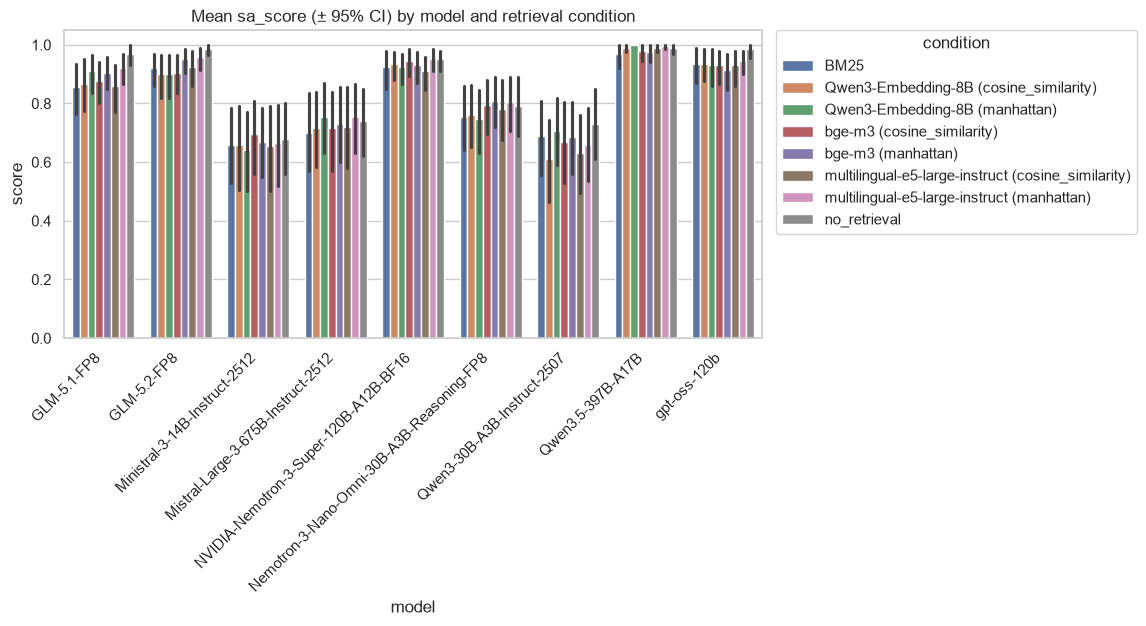

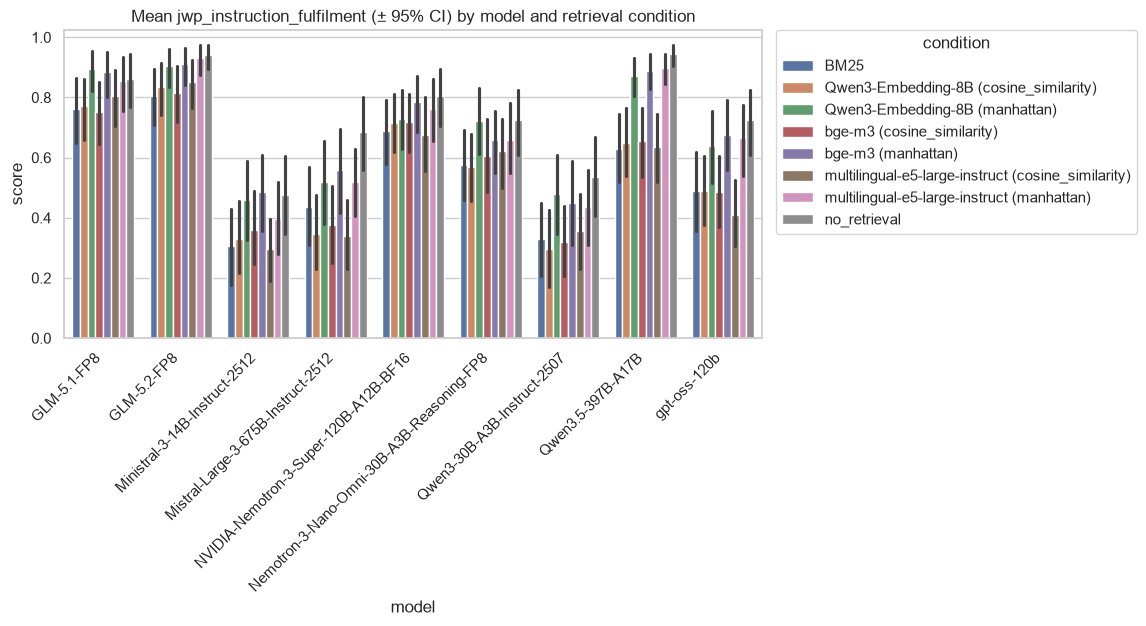

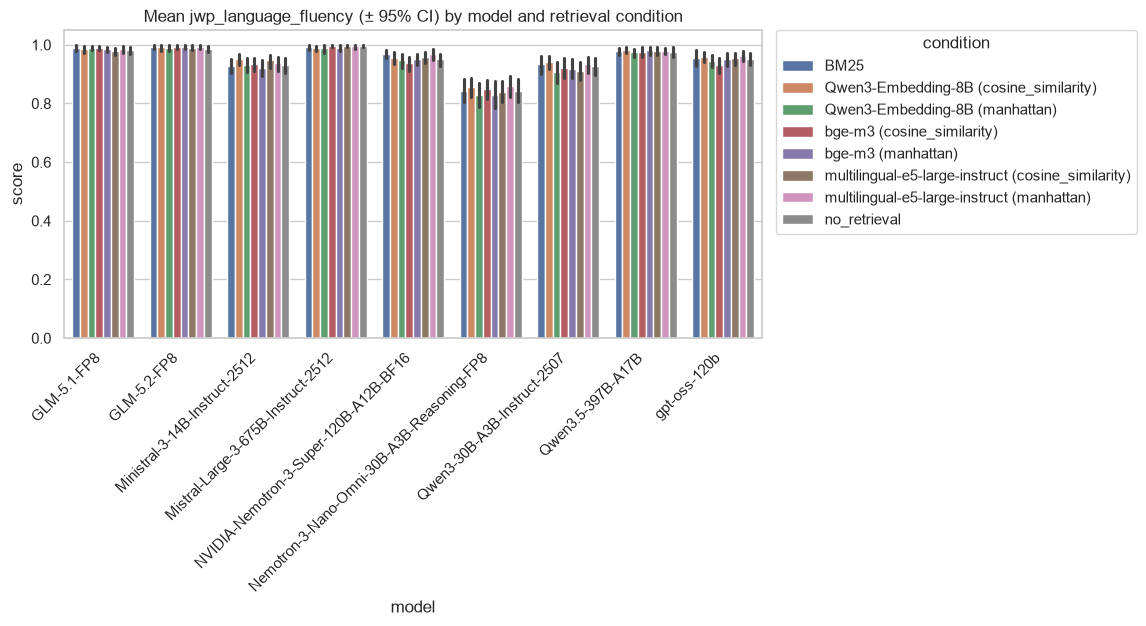

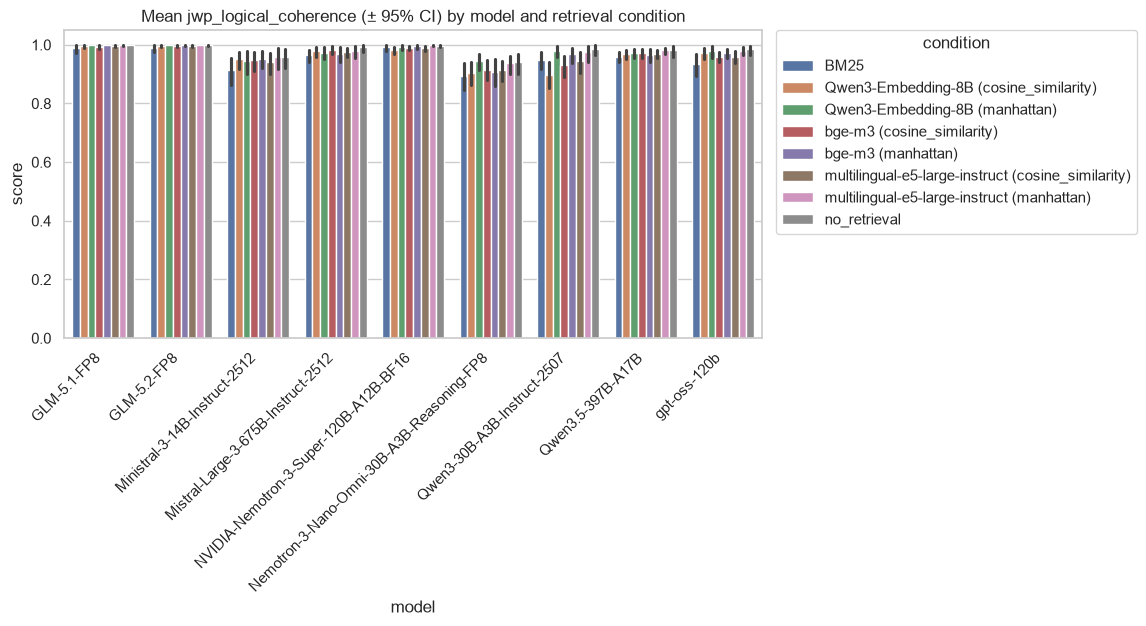

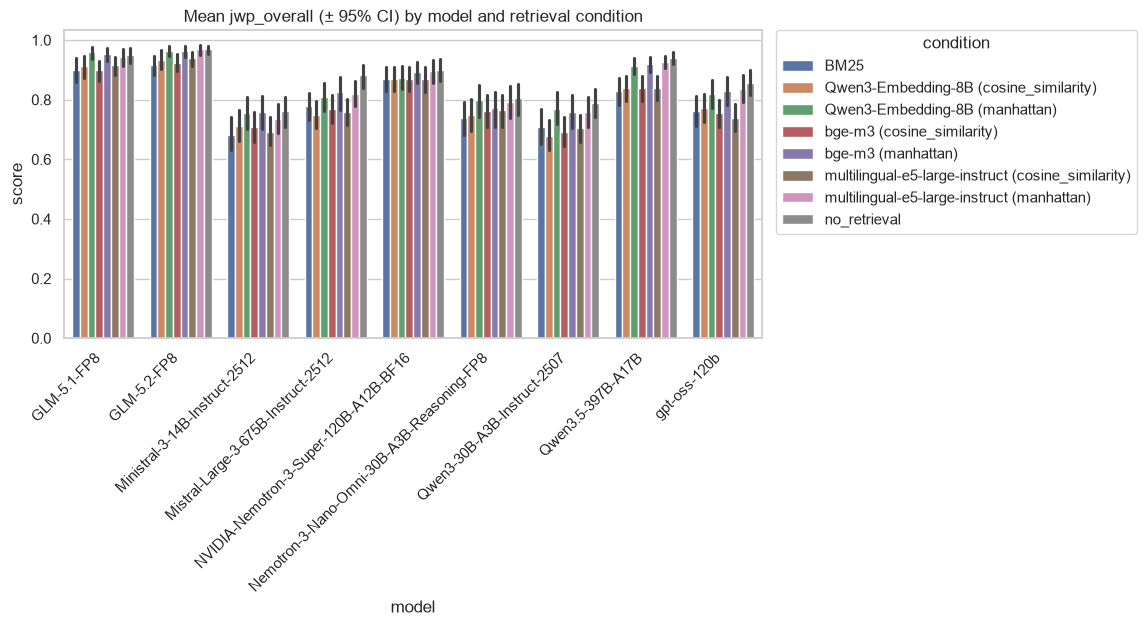

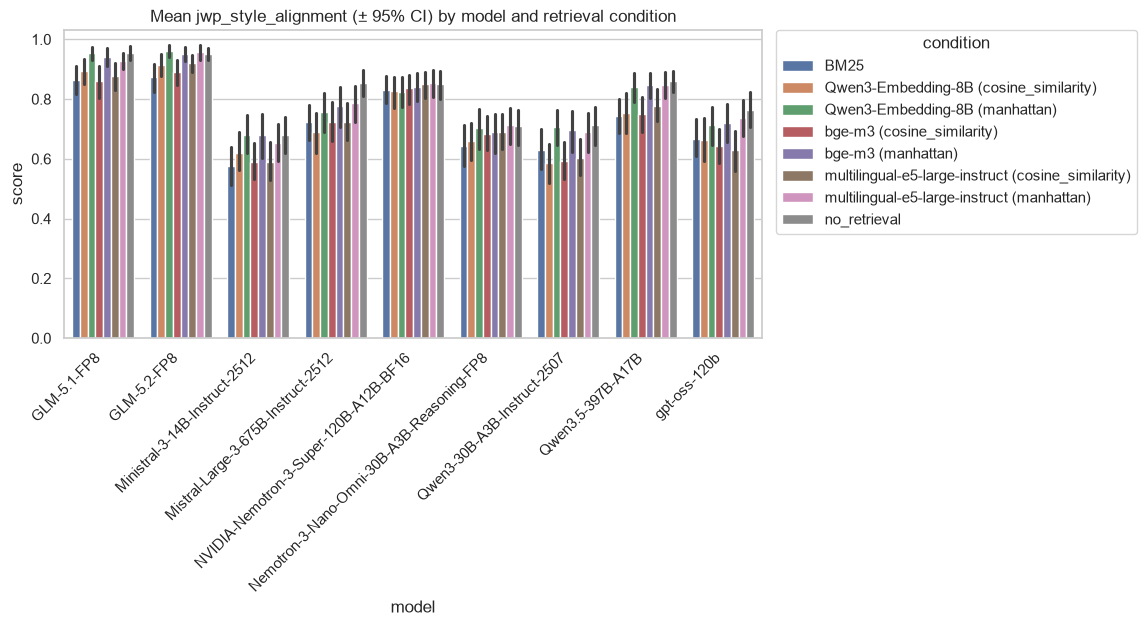

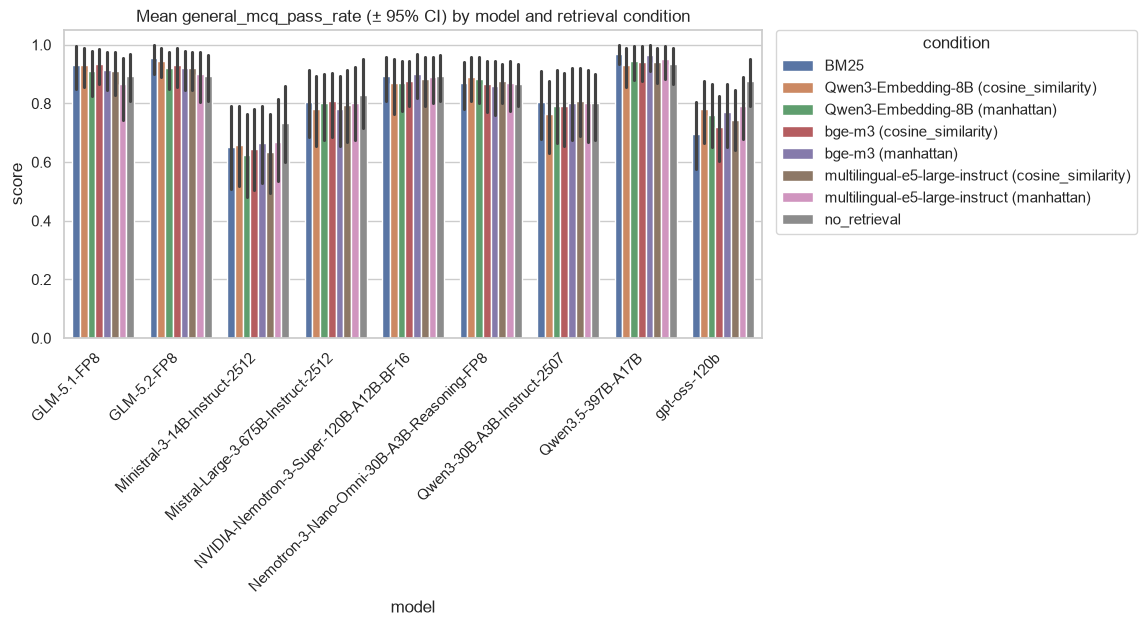

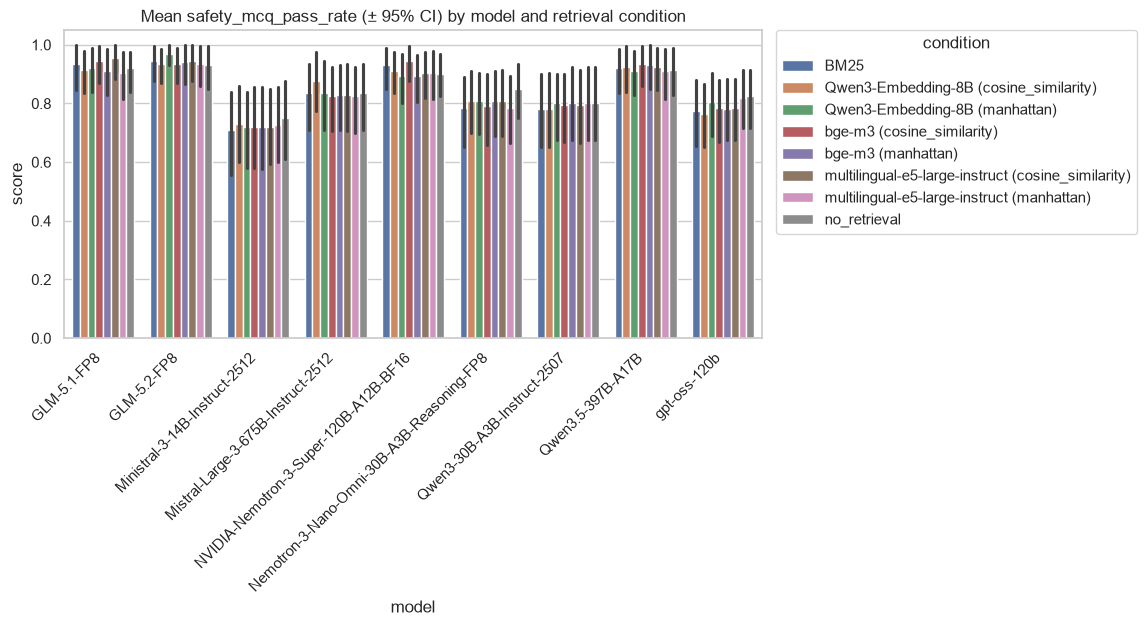

In [376]:
def plot_bar_with_ci(df, metrics=None,  figsize_per_plot=(9, 4)):
    metrics = metrics or df['metric'].unique()
    for metric in metrics:
        sub = df[df['metric'] == metric]
        plt.figure(figsize=figsize_per_plot)
        order = sorted(sub['model'].unique())
        sns.barplot(data=sub, x='model', y='score', hue='condition', order=order, errorbar=('ci', 95))
        plt.title(f'Mean {metric} (± 95% CI) by model and retrieval condition')
        plt.xticks(rotation=45, ha='right')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='condition')
        plt.show()

plot_bar_with_ci(agg_df)


## Paired t-test against a control retriever

For each model and each metric, we pair up scores on the *same item* (`task` + `idx`) between a
treatment condition (e.g. `Qwen3-Embedding-8B` + `cosine_similarity`) and the `BM25` control, then
run:

- a **paired t-test** (`scipy.stats.ttest_rel`) — the parametric standard, assumes the differences are
  roughly normal;
- a **Wilcoxon signed-rank test** as a non-parametric backup — several of your metrics (`sa_score`,
  the `jwp_*` columns) are Likert-style ordinal ratings, where the t-test's normality assumption is
  shaky, so it's worth checking both agree;
- **Cohen's d for paired samples** (mean difference / SD of differences) as an effect size, since a
  tiny p-value with thousands of items can come from a practically meaningless difference.

Running this many tests (9 models × several conditions × 8 metrics) inflates the false-positive rate,
so p-values are corrected with the **Holm–Bonferroni** method (less conservative than plain Bonferroni,
still controls the family-wise error rate).

In [377]:
CONTROL_RETRIEVER = 'no_retrieval'

def paired_tests_vs_control(df, control=CONTROL_RETRIEVER):
    results = []
    control_df = df[df['retriever'] == control]
    treat_df = df[df['retriever'] != control]

    conditions = treat_df[['retriever', 'distance_metric', 'condition']].drop_duplicates()
    for _, cond in conditions.iterrows():
        r, dm, label = cond['retriever'], cond['distance_metric'], cond['condition']
        cond_df = treat_df[treat_df['condition'] == label]

        for model in sorted(cond_df['model'].unique()):
            for metric in sorted(cond_df['metric'].unique()):
                a = cond_df[(cond_df['model'] == model) & (cond_df['metric'] == metric)]
                b = control_df[(control_df['model'] == model) & (control_df['metric'] == metric)]
                merged = a.merge(b, on=['model', 'task', 'idx', 'metric'], suffixes=('_treat', '_control'))
                if len(merged) < 2:
                    continue

                diffs = merged['score_treat'] - merged['score_control']
                t_stat, t_p = stats.ttest_rel(merged['score_treat'], merged['score_control'])

                if diffs.std() > 0:
                    w_stat, w_p = stats.wilcoxon(merged['score_treat'], merged['score_control'])
                else:
                    w_stat, w_p = np.nan, np.nan

                sd_diff = diffs.std(ddof=1)
                cohens_d = diffs.mean() / sd_diff if sd_diff > 0 else np.nan

                results.append({
                    'condition': label, 'retriever': r, 'distance_metric': dm,
                    'model': model, 'metric': metric, 'n_pairs': len(merged),
                    'mean_diff': diffs.mean(), 'cohens_d': cohens_d,
                    't_stat': t_stat, 't_p_value': t_p,
                    'wilcoxon_stat': w_stat, 'wilcoxon_p_value': w_p,
                })

    results_df_ = pd.DataFrame(results)
    if not results_df_.empty:
        # Holm-Bonferroni correction, applied within the whole family of tests run here
        results_df_['t_p_holm'] = multipletests(results_df_['t_p_value'], method='holm')[1]
        results_df_['significant_at_0.05'] = results_df_['t_p_holm'] < 0.05
    return results_df_

paired_ttest_results = paired_tests_vs_control(tidy_df)
paired_ttest_results.sort_values('t_p_holm')


,condition,retriever,distance_metric,model,metric,n_pairs,mean_diff,cohens_d,t_stat,t_p_value,wilcoxon_stat,wilcoxon_p_value,t_p_holm,significant_at_0.05
100,Qwen3-Embedding-8B (cosine_similarity),Qwen3-Embedding-8B,cosine_similarity,Mistral-Large-3-675B-Instruct-2512,jwp_overall,1000,-0.131667,-0.748988,-23.685068,8.770593e-99,18226.0,8.279410e-78,4.420379e-96,True
388,multilingual-e5-large-instruct (cosine_similar...,multilingual-e5-large-instruct,cosine_similarity,Mistral-Large-3-675B-Instruct-2512,jwp_overall,1000,-0.123333,-0.673673,-21.303397,2.568733e-83,21768.5,7.509024e-67,1.292073e-80,True
97,Qwen3-Embedding-8B (cosine_similarity),Qwen3-Embedding-8B,cosine_similarity,Mistral-Large-3-675B-Instruct-2512,jwp_instruction_fulfilment,1000,-0.340000,-0.660893,-20.899261,9.487744e-81,3810.0,3.985294e-68,4.762847e-78,True
385,multilingual-e5-large-instruct (cosine_similar...,multilingual-e5-large-instruct,cosine_similarity,Mistral-Large-3-675B-Instruct-2512,jwp_instruction_fulfilment,1000,-0.345000,-0.642576,-20.320035,4.200413e-77,6324.0,1.458418e-65,2.104407e-74,True
60,BM25,BM25,NaN,Qwen3.5-397B-A17B,jwp_overall,995,-0.113065,-0.628091,-19.812261,6.901200e-74,21544.5,1.794022e-61,3.450600e-71,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,Qwen3-Embedding-8B (manhattan),Qwen3-Embedding-8B,manhattan,Mistral-Large-3-675B-Instruct-2512,safety_mcq_pass_rate,1000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,False
199,Qwen3-Embedding-8B (manhattan),Qwen3-Embedding-8B,manhattan,Qwen3-30B-A3B-Instruct-2507,safety_mcq_pass_rate,1000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,False
291,bge-m3 (manhattan),bge-m3,manhattan,GLM-5.1-FP8,jwp_logical_coherence,1000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,False
343,bge-m3 (manhattan),bge-m3,manhattan,Qwen3-30B-A3B-Instruct-2507,safety_mcq_pass_rate,1000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,False


In [378]:
# Quick view: which (condition, model, metric) combinations show a significant, Holm-corrected
# improvement or regression relative to BM25
significant = paired_ttest_results[paired_ttest_results['significant_at_0.05']].sort_values('cohens_d')
significant


,condition,retriever,distance_metric,model,metric,n_pairs,mean_diff,cohens_d,t_stat,t_p_value,wilcoxon_stat,wilcoxon_p_value,t_p_holm,significant_at_0.05
100,Qwen3-Embedding-8B (cosine_similarity),Qwen3-Embedding-8B,cosine_similarity,Mistral-Large-3-675B-Instruct-2512,jwp_overall,1000,-0.131667,-0.748988,-23.685068,8.770593e-99,18226.0,8.279410e-78,4.420379e-96,True
388,multilingual-e5-large-instruct (cosine_similar...,multilingual-e5-large-instruct,cosine_similarity,Mistral-Large-3-675B-Instruct-2512,jwp_overall,1000,-0.123333,-0.673673,-21.303397,2.568733e-83,21768.5,7.509024e-67,1.292073e-80,True
97,Qwen3-Embedding-8B (cosine_similarity),Qwen3-Embedding-8B,cosine_similarity,Mistral-Large-3-675B-Instruct-2512,jwp_instruction_fulfilment,1000,-0.340000,-0.660893,-20.899261,9.487744e-81,3810.0,3.985294e-68,4.762847e-78,True
385,multilingual-e5-large-instruct (cosine_similar...,multilingual-e5-large-instruct,cosine_similarity,Mistral-Large-3-675B-Instruct-2512,jwp_instruction_fulfilment,1000,-0.345000,-0.642576,-20.320035,4.200413e-77,6324.0,1.458418e-65,2.104407e-74,True
60,BM25,BM25,NaN,Qwen3.5-397B-A17B,jwp_overall,995,-0.113065,-0.628091,-19.812261,6.901200e-74,21544.5,1.794022e-61,3.450600e-71,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,Qwen3-Embedding-8B (cosine_similarity),Qwen3-Embedding-8B,cosine_similarity,Mistral-Large-3-675B-Instruct-2512,safety_mcq_pass_rate,1000,0.040000,0.222111,7.023769,3.988968e-12,0.0,2.163555e-10,1.420073e-09,True
8,BM25,BM25,NaN,GLM-5.2-FP8,general_mcq_pass_rate,1000,0.060000,0.244014,7.716414,2.890972e-14,2200.0,7.082848e-11,1.069659e-11,True
255,bge-m3 (cosine_similarity),bge-m3,cosine_similarity,NVIDIA-Nemotron-3-Super-120B-A12B-BF16,safety_mcq_pass_rate,1000,0.045000,0.296734,9.383557,4.160194e-20,950.0,7.166137e-19,1.697359e-17,True
367,multilingual-e5-large-instruct (cosine_similar...,multilingual-e5-large-instruct,cosine_similarity,GLM-5.1-FP8,safety_mcq_pass_rate,1000,0.035000,0.298061,9.425513,2.883708e-20,0.0,8.467229e-19,1.179436e-17,True


## ANOVA: which parts of the pipeline drive performance

The original cell is generalized into a reusable function so it can be run for every metric, and
extended with:

- **effect size (η²)** per factor — with thousands of rows, tiny effects become "significant" by
  p-value alone; η² tells you how much of the variance each factor actually explains;
- an **interaction term** option (`retriever:model`, `distance_metric:model`) to check whether the
  retrieval setup helps some models more than others, rather than assuming a uniform effect;
- a **Kruskal-Wallis** test as a non-parametric complement to the `model` factor (same reasoning as
  the Wilcoxon test above — your subjective scores are ordinal);
- a **Tukey HSD post-hoc test** on `model`, since a significant ANOVA only tells you *that* models
  differ, not *which* ones.

In [379]:
def run_anova(df, score_col, formula_rhs='C(retriever) + C(distance_metric) + C(model)', typ=2):
    d = df.copy()
    d['distance_metric'] = d['distance_metric'].fillna('None')
    formula = f'{score_col} ~ {formula_rhs}'
    model = ols(formula, data=d).fit()
    table = sm.stats.anova_lm(model, typ=typ)
    table['eta_sq'] = table['sum_sq'] / table['sum_sq'].sum()
    return table, model

# Run the main-effects ANOVA for every metric (using the embedding retrievers, as in the original cell)
embedding_retrievers = ['Qwen3-Embedding-8B', 'bge-m3']

anova_tables = {}
for metric in sorted(agg_df['metric'].unique()):
    metric_df = agg_df[(agg_df['metric'] == metric) & (agg_df['retriever'].isin(embedding_retrievers))]
    if metric_df.empty:
        continue
    table, _ = run_anova(metric_df, 'score')
    anova_tables[metric] = table
    print(f'--- {metric} ---')
    print(table)
    print()


--- general_mcq_pass_rate ---
                        sum_sq      df          F        PR(>F)    eta_sq
C(retriever)          0.001000     1.0   0.009675  9.216591e-01  0.000006
C(distance_metric)    0.000444     1.0   0.004300  9.477259e-01  0.000003
C(model)             12.302889     8.0  14.878776  4.368078e-21  0.076891
Residual            147.700556  1429.0        NaN           NaN  0.923100

--- jwp_instruction_fulfilment ---
                        sum_sq      df          F        PR(>F)    eta_sq
C(retriever)          0.030093     1.0   0.233953  6.286822e-01  0.000129
C(distance_metric)    6.571766     1.0  51.091509  1.403606e-12  0.028248
C(model)             42.877722     8.0  41.668550  3.847702e-60  0.184305
Residual            183.165350  1424.0        NaN           NaN  0.787317

--- jwp_language_fluency ---
                      sum_sq      df          F        PR(>F)    eta_sq
C(retriever)        0.005816     1.0   1.122239  2.896165e-01  0.000564
C(distance_metric)  

In [380]:
# Interaction model: does the retrieval condition help some models more than others?
interaction_tables = {}
for metric in sorted(agg_df['metric'].unique()):
    metric_df = agg_df[(agg_df['metric'] == metric) & (agg_df['retriever'].isin(embedding_retrievers))]
    if metric_df.empty:
        continue
    table, _ = run_anova(
        metric_df, 'score',
        formula_rhs='C(retriever) + C(distance_metric) + C(model) + C(retriever):C(model) + C(distance_metric):C(model)'
    )
    interaction_tables[metric] = table
    print(f'--- {metric} (with interactions) ---')
    print(table)
    print()


--- general_mcq_pass_rate (with interactions) ---
                                 sum_sq      df          F        PR(>F)  \
C(retriever)                   0.001000     1.0   0.009578  9.220533e-01   
C(distance_metric)             0.000444     1.0   0.004257  9.479894e-01   
C(model)                      12.302889     8.0  14.728993  7.555869e-21   
C(retriever):C(model)          0.093000     8.0   0.111339  9.988414e-01   
C(distance_metric):C(model)    0.075556     8.0   0.090455  9.994607e-01   
Residual                     147.532000  1413.0        NaN           NaN   

                               eta_sq  
C(retriever)                 0.000006  
C(distance_metric)           0.000003  
C(model)                     0.076891  
C(retriever):C(model)        0.000581  
C(distance_metric):C(model)  0.000472  
Residual                     0.922047  

--- jwp_instruction_fulfilment (with interactions) ---
                                 sum_sq      df          F        PR(>F)  \
C(ret

In [381]:
# Non-parametric complement to the 'model' factor + post-hoc pairwise comparisons
for metric in sorted(agg_df['metric'].unique()):
    metric_df = agg_df[agg_df['metric'] == metric]
    groups = [g['score'].values for _, g in metric_df.groupby('model')]
    if len(groups) < 2:
        continue
    h_stat, kw_p = stats.kruskal(*groups)
    print(f'{metric}: Kruskal-Wallis H={h_stat:.2f}, p={kw_p:.3e}')

    tukey = pairwise_tukeyhsd(endog=metric_df['score'], groups=metric_df['model'], alpha=0.05)
    print(tukey)
    print()


general_mcq_pass_rate: Kruskal-Wallis H=188.76, p=1.482e-36
                                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                                     
                  group1                                     group2                   meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------
                               GLM-5.1-FP8                                GLM-5.2-FP8   0.0119 0.9999 -0.0666  0.0904  False
                               GLM-5.1-FP8              Ministral-3-14B-Instruct-2512  -0.2506    0.0 -0.3291 -0.1721   True
                               GLM-5.1-FP8         Mistral-Large-3-675B-Instruct-2512  -0.1112 0.0004 -0.1897 -0.0328   True
                               GLM-5.1-FP8     NVIDIA-Nemotron-3-Super-120B-A12B-BF16  -0.0262 0.9822 -0.1047  0.0522  False
                               GLM-5.1-FP8 Nemotron-3-Nano-Omni-3

## Correlation between model size and performance

For MoE models, total and active parameter counts can tell very different stories, so both are kept
and correlated separately. Because parameter counts span two orders of magnitude, correlations are
computed against `log10(params)` and both **Pearson** (linear) and **Spearman** (monotonic rank,
more robust with only ~9 models and possible outliers) are reported.

In [382]:
names = ['GLM-5.1-FP8', 'GLM-5.2-FP8','Ministral-3-14B-Instruct-2512','Mistral-Large-3-675B-Instruct-2512','NVIDIA-Nemotron-3-Super-120B-A12B-BF16','Nemotron-3-Nano-Omni-30B-A3B-Reasoning-FP8','Qwen3-30B-A3B-Instruct-2507','Qwen3.5-397B-A17B','gpt-oss-120b']
total_params = [754,753,14,675,31,120,31,403,120]
active_params = [40,40,14,41,12,3,3,17,5.1]
model_size_dict = {name : {'total_params_b' : total_param, 'active_params_b': active_param} for name, total_param, active_param in zip(names, total_params, active_params)}
model_size_df = pd.DataFrame.from_dict(model_size_dict, orient='index').reset_index(names='model')
model_size_df

,model,total_params_b,active_params_b
0,GLM-5.1-FP8,754,40.0
1,GLM-5.2-FP8,753,40.0
2,Ministral-3-14B-Instruct-2512,14,14.0
3,Mistral-Large-3-675B-Instruct-2512,675,41.0
4,NVIDIA-Nemotron-3-Super-120B-A12B-BF16,31,12.0
5,Nemotron-3-Nano-Omni-30B-A3B-Reasoning-FP8,120,3.0
6,Qwen3-30B-A3B-Instruct-2507,31,3.0
7,Qwen3.5-397B-A17B,403,17.0
8,gpt-oss-120b,120,5.1


In [383]:
def correlate_size_vs_performance(agg_df, model_size_df, size_col='total_params_b'):
    perf_df = agg_df.groupby(['model', 'metric'])['score'].mean().reset_index()
    merged = perf_df.merge(model_size_df[['model', size_col]], on='model').dropna(subset=[size_col])
    merged['log_size'] = merged[size_col]

    rows = []
    for metric in sorted(merged['metric'].unique()):
        sub = merged[merged['metric'] == metric]
        if sub['model'].nunique() < 3:
            continue
        pearson_r, pearson_p = stats.pearsonr(sub['log_size'], sub['score'])
        spearman_r, spearman_p = stats.spearmanr(sub['log_size'], sub['score'])
        rows.append({
            'metric': metric, 'size_col': size_col, 'n_models': sub['model'].nunique(),
            'pearson_r': pearson_r, 'pearson_p': pearson_p,
            'spearman_r': spearman_r, 'spearman_p': spearman_p,
        })
    return pd.DataFrame(rows), merged

size_corr_total, merged_total = correlate_size_vs_performance(agg_df, model_size_df, 'total_params_b')
size_corr_active, merged_active = correlate_size_vs_performance(agg_df, model_size_df, 'active_params_b')

print('--- vs. total parameters ---')
display(size_corr_total)
print('--- vs. active parameters ---')
display(size_corr_active)


--- vs. total parameters ---


,metric,size_col,n_models,pearson_r,pearson_p,spearman_r,spearman_p
0,general_mcq_pass_rate,total_params_b,9,0.519830,0.151441,0.655485,0.055284
1,jwp_instruction_fulfilment,total_params_b,9,0.554672,0.121145,0.731118,0.025215
2,jwp_language_fluency,total_params_b,9,0.673683,0.046648,0.739522,0.022768
3,jwp_logical_coherence,total_params_b,9,0.626764,0.070865,0.680696,0.043566
4,jwp_overall,total_params_b,9,0.701706,0.035128,0.815155,0.007424
5,jwp_style_alignment,total_params_b,9,0.749273,0.020130,0.756329,0.018354
6,sa_score,total_params_b,9,0.315150,0.408773,0.344550,0.363871
7,safety_mcq_pass_rate,total_params_b,9,0.654078,0.055992,0.781540,0.012862


--- vs. active parameters ---


,metric,size_col,n_models,pearson_r,pearson_p,spearman_r,spearman_p
0,general_mcq_pass_rate,active_params_b,9,0.327415,0.389744,0.411779,0.270805
1,jwp_instruction_fulfilment,active_params_b,9,0.424939,0.254233,0.386568,0.304082
2,jwp_language_fluency,active_params_b,9,0.751233,0.019626,0.941210,0.000153
3,jwp_logical_coherence,active_params_b,9,0.696533,0.037097,0.714311,0.030617
4,jwp_overall,active_params_b,9,0.636870,0.065105,0.638678,0.064106
5,jwp_style_alignment,active_params_b,9,0.720353,0.028596,0.605063,0.084283
6,sa_score,active_params_b,9,0.171784,0.658537,0.075633,0.846654
7,safety_mcq_pass_rate,active_params_b,9,0.563235,0.114307,0.588256,0.095679


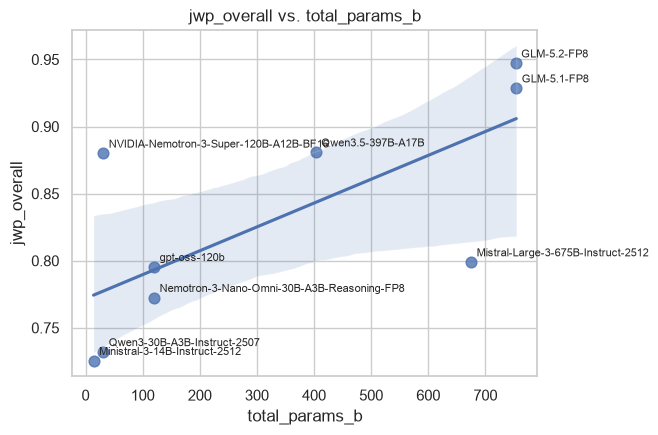

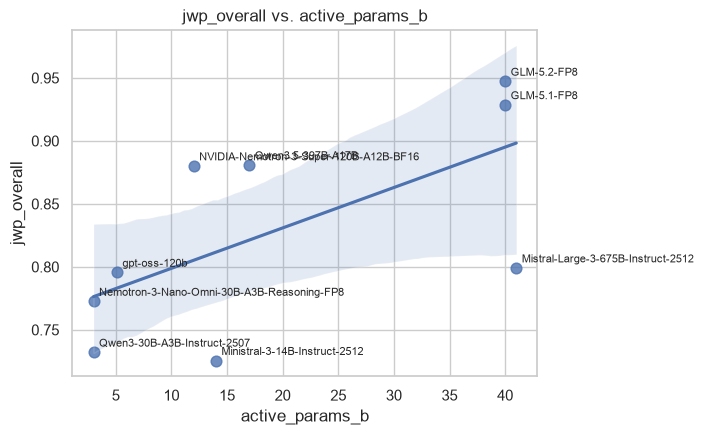

In [384]:
def plot_size_vs_metric(merged, metric, size_col='total_params_b'):
    sub = merged[merged['metric'] == metric]
    plt.figure(figsize=(6, 4.5))
    sns.regplot(data=sub, x='log_size', y='score', scatter_kws={'s': 60})
    for _, row in sub.iterrows():
        plt.annotate(row['model'], (row['log_size'], row['score']), fontsize=8,
                     xytext=(4, 4), textcoords='offset points')
    plt.xlabel(f'{size_col}')
    plt.ylabel(metric)
    plt.title(f'{metric} vs. {size_col}')
    plt.show()

plot_size_vs_metric(merged_total, metric='jwp_overall', size_col='total_params_b')
plot_size_vs_metric(merged_active, metric='jwp_overall', size_col='active_params_b')


## Make plots for report

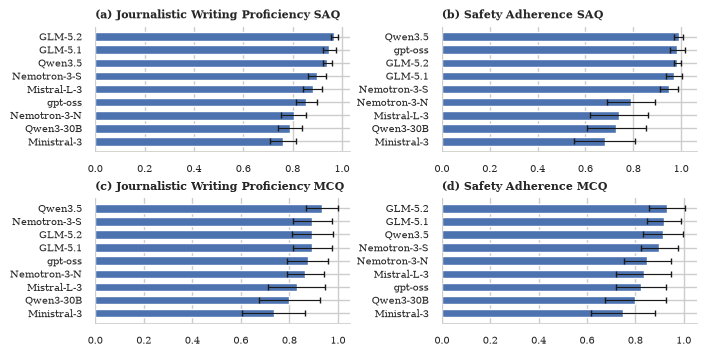

Saved to ../figures/model_ranking_no_retrieval.pdf (vector, use this one in LaTeX)


In [385]:
# ---- ACM-appropriate styling -------------------------------------------------
# ACM's template body text is ~9-10pt at column width ~3.33in. Keep fonts a touch
# smaller so labels don't dominate the panel, and use a serif face to match the
# ACM template (which uses Linux Libertine) reasonably closely.
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,   # embed proper (non-Type-3) fonts, required by many venues
    "ps.fonttype": 42,
})
 
OUTDIR = "../figures"  # change to wherever your LaTeX project expects images
os.makedirs(OUTDIR, exist_ok=True)
 
# Optional: shorten long model names for axis labels only (keep full names in tables)
SHORT_NAMES = {
    "Mistral-Large-3-675B-Instruct-2512": "Mistral-L-3",
    "Ministral-3-14B-Instruct-2512": "Ministral-3",
    "NVIDIA-Nemotron-3-Super-120B-A12B-BF16": "Nemotron-3-S",
    "Nemotron-3-Nano-Omni-30B-A3B-Reasoning-FP8": "Nemotron-3-N",
    "Qwen3-30B-A3B-Instruct-2507": "Qwen3-30B",
    "Qwen3.5-397B-A17B": "Qwen3.5",
    "gpt-oss-120b": "gpt-oss",
    "GLM-5.1-FP8": "GLM-5.1",
    "GLM-5.2-FP8": "GLM-5.2",
}
 
fig, axes = plt.subplots(2, 2, figsize=(7.0, 3.5))  # ~full ACM text width, 1 row
 
# --- Panel (a): model ranking on jwp_overall, collapsed across retrieval condition ---
ax = axes[0][0]
metric_df = agg_df[(agg_df["metric"] == "jwp_overall") & (agg_df["retriever"] == 'no_retrieval')].copy()
model_stats = (metric_df.groupby("model")["score"]
               .agg(["mean", "sem"])
               .sort_values("mean", ascending=True))
labels = [SHORT_NAMES.get(m, m) for m in model_stats.index]
y_pos = np.arange(len(model_stats))
 
ax.barh(y_pos, model_stats["mean"], xerr=1.96 * model_stats["sem"],
        color="#4C72B0", height=0.65, error_kw={"linewidth": 0.8, "capsize": 2})
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
# ax.set_xlabel("Mean JWP (overall) (± 95% CI)")
ax.set_title("(a) Journalistic Writing Proficiency SAQ", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
 
ax = axes[0][1]
metric_df = agg_df[(agg_df["metric"] == "sa_score") & (agg_df["retriever"] == 'no_retrieval')].copy()
model_stats = (metric_df.groupby("model")["score"]
               .agg(["mean", "sem"])
               .sort_values("mean", ascending=True))
labels = [SHORT_NAMES.get(m, m) for m in model_stats.index]
y_pos = np.arange(len(model_stats))
 
ax.barh(y_pos, model_stats["mean"], xerr=1.96 * model_stats["sem"],
        color="#4C72B0", height=0.65, error_kw={"linewidth": 0.8, "capsize": 2})
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
# ax.set_xlabel("Mean SA (overall) (± 95% CI)")
ax.set_title("(b) Safety Adherence SAQ", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1][0]
metric_df = agg_df[(agg_df["metric"] == "general_mcq_pass_rate") & (agg_df["retriever"] == 'no_retrieval')].copy()
model_stats = (metric_df.groupby("model")["score"]
               .agg(["mean", "sem"])
               .sort_values("mean", ascending=True))
labels = [SHORT_NAMES.get(m, m) for m in model_stats.index]
y_pos = np.arange(len(model_stats))
 
ax.barh(y_pos, model_stats["mean"], xerr=1.96 * model_stats["sem"],
        color="#4C72B0", height=0.65, error_kw={"linewidth": 0.8, "capsize": 2})
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
# ax.set_xlabel("Mean JWP (overall) (± 95% CI)")
ax.set_title("(c) Journalistic Writing Proficiency MCQ", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1][1]
metric_df = agg_df[(agg_df["metric"] == "safety_mcq_pass_rate") & (agg_df["retriever"] == 'no_retrieval')].copy()
model_stats = (metric_df.groupby("model")["score"]
               .agg(["mean", "sem"])
               .sort_values("mean", ascending=True))
labels = [SHORT_NAMES.get(m, m) for m in model_stats.index]
y_pos = np.arange(len(model_stats))
 
ax.barh(y_pos, model_stats["mean"], xerr=1.96 * model_stats["sem"],
        color="#4C72B0", height=0.65, error_kw={"linewidth": 0.8, "capsize": 2})
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
# ax.set_xlabel("Mean JWP (overall) (± 95% CI)")
ax.set_title("(d) Safety Adherence MCQ", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
 
fig.tight_layout(pad=0.6)
fig.savefig(f"{OUTDIR}/model_ranking_no_retrieval.pdf", bbox_inches="tight")
fig.savefig(f"{OUTDIR}/model_ranking_no_retrieval.png", dpi=300, bbox_inches="tight")  # fallback raster
plt.show()
 
print(f"Saved to {OUTDIR}/model_ranking_no_retrieval.pdf (vector, use this one in LaTeX)")


In [386]:
def sig_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""
 
FACTOR_LABELS = {
    "C(retriever)": "Retriever",
    "C(distance_metric)": "Dist.\\ metric",
    "C(model)": "Model",
}
 
# Nicer display names for metrics (edit to taste)
METRIC_LABELS = {
    "jwp_language_fluency": "Fluency",
    "jwp_logical_coherence": "Coherence",
    "jwp_style_alignment": "Style align.",
    "jwp_instruction_fulfilment": "Instr.\\ fulfil.",
    "jwp_overall": "Overall",
    "sa_score": "Safety (subj.)",
    "safety_mcq_pass_rate": "Safety (MCQ)",
    "general_mcq_pass_rate": "General (MCQ)",
}
 
rows = []
for metric, table in anova_tables.items():
    row = {"Metric": METRIC_LABELS.get(metric, metric)}
    for factor in ["C(retriever)", "C(distance_metric)", "C(model)"]:
        if factor in table.index:
            eta = table.loc[factor, "eta_sq"]
            p = table.loc[factor, "PR(>F)"]
            row[FACTOR_LABELS[factor]] = f"{eta:.3f}{sig_stars(p)}"
        else:
            row[FACTOR_LABELS[factor]] = "--"
    rows.append(row)
 
summary_df = pd.DataFrame(rows).set_index("Metric")
# Order metrics: general quality, then safety
metric_order = ["Fluency", "Coherence", "Style align.", "Instr.\\ fulfil.",
                 "Overall", "Safety (subj.)", "Safety (MCQ)", "General (MCQ)"]
summary_df = summary_df.reindex([METRIC_LABELS.get(m, m) for m in anova_tables.keys()])
 
latex_table = summary_df.to_latex(
    escape=False,
    column_format="l" + "r" * len(summary_df.columns),
    caption=(
        "Effect size ($\\eta^2$) of each pipeline factor on each outcome metric "
        "(Type II ANOVA). Model choice dominates every metric; retriever and "
        "distance metric have small, mostly non-significant effects, except on "
        "subjective judged-quality scores. $^{*}p<.05$, $^{**}p<.01$, $^{***}p<.001$."
    ),
    label="tab:anova",
)
 
# ACM's sigconf template is happy with booktabs; wrap in \small since this is a
# dense table and the page is tight on space.
latex_table = latex_table.replace("\\begin{table}", "\\begin{table}[t]\n\\small")
 
# with open("figures/anova_summary_table.tex", "w") as f:
#     f.write(latex_table)
 
print(latex_table)


\begin{table}[t]
\small
\caption{Effect size ($\eta^2$) of each pipeline factor on each outcome metric (Type II ANOVA). Model choice dominates every metric; retriever and distance metric have small, mostly non-significant effects, except on subjective judged-quality scores. $^{*}p<.05$, $^{**}p<.01$, $^{***}p<.001$.}
\label{tab:anova}
\begin{tabular}{lrrr}
\toprule
 & Retriever & Dist.\ metric & Model \\
Metric &  &  &  \\
\midrule
General (MCQ) & 0.000 & 0.000 & 0.077*** \\
Instr.\ fulfil. & 0.000 & 0.028*** & 0.184*** \\
Fluency & 0.001 & 0.001 & 0.282*** \\
Coherence & 0.000 & 0.004* & 0.102*** \\
Overall & 0.000 & 0.023*** & 0.229*** \\
Style align. & 0.000 & 0.021*** & 0.238*** \\
Safety (subj.) & 0.000 & 0.000 & 0.133*** \\
Safety (MCQ) & 0.000 & 0.000 & 0.050*** \\
\bottomrule
\end{tabular}
\end{table}



In [387]:
METRIC_LABELS = {
    "jwp_language_fluency": "Fluency",
    "jwp_logical_coherence": "Coherence",
    "jwp_style_alignment": "Style align.",
    "jwp_instruction_fulfilment": "Instr.\\ fulfil.",
    "jwp_overall": "Overall",
    "sa_score": "Safety (subj.)",
    "safety_mcq_pass_rate": "Safety (MCQ)",
    "general_mcq_pass_rate": "General (MCQ)",
}
 
def short_condition(row):
    """Abbreviate 'condition + model' for a compact footnote-style example cell."""
    cond = row["condition"]
    model = row["model"]
    model_short = SHORT_NAMES[model]
    return f"{model_short}/{cond}"
 
rows = []
for metric, sub in paired_ttest_results.groupby("metric"):
    sig = sub[sub["significant_at_0.05"]]
    improved = sig[sig["mean_diff"] > 0]
    regressed = sig[sig["mean_diff"] < 0]
 
    row = {
        "Metric": METRIC_LABELS.get(metric, metric),
        "Improved": len(improved),
        "Regressed": len(regressed),
        "n.s.": len(sub) - len(sig),
    }
 
    if len(regressed) > 0:
        worst = regressed.loc[regressed["cohens_d"].idxmin()]
        row["Largest regression"] = f"{short_condition(worst)} ($d={worst['cohens_d']:.2f}$)"
    else:
        row["Largest regression"] = "--"
 
    if len(improved) > 0:
        best = improved.loc[improved["cohens_d"].idxmax()]
        row["Largest gain"] = f"{short_condition(best)} ($d={best['cohens_d']:.2f}$)"
    else:
        row["Largest gain"] = "--"
 
    rows.append(row)
 
summary_df = pd.DataFrame(rows).set_index("Metric")
summary_df = summary_df[["Improved", "Regressed", "n.s.", "Largest regression", "Largest gain"]]
summary_df
latex_table = summary_df.to_latex(
    escape=False,
    column_format="lrrrrll",
    caption=(
        "Paired t-tests of each retrieval condition against the no-retrieval "
        "control (Holm-corrected, $\\alpha=.05$), summarized per metric. "
        "\\emph{N} is the number of (condition, model) pairs tested; "
        "\\emph{Improved}/\\emph{Regressed} count significant differences in "
        "each direction relative to no retrieval. Retrieval regresses "
        "judged-quality metrics for several models more often than it helps, "
        "while MCQ-style metrics show the reverse pattern."
    ),
    label="tab:ttest",
)
latex_table = latex_table.replace("\\begin{table}", "\\begin{table}[t]\n\\small")
 
print(latex_table)


\begin{table}[t]
\small
\caption{Paired t-tests of each retrieval condition against the no-retrieval control (Holm-corrected, $\alpha=.05$), summarized per metric. \emph{N} is the number of (condition, model) pairs tested; \emph{Improved}/\emph{Regressed} count significant differences in each direction relative to no retrieval. Retrieval regresses judged-quality metrics for several models more often than it helps, while MCQ-style metrics show the reverse pattern.}
\label{tab:ttest}
\begin{tabular}{lrrrrll}
\toprule
 & Improved & Regressed & n.s. & Largest regression & Largest gain \\
Metric &  &  &  &  &  \\
\midrule
General (MCQ) & 11 & 27 & 25 & gpt-oss/bge-m3 (cosine_similarity) ($d=-0.59$) & Qwen3.5/BM25 ($d=0.32$) \\
Instr.\ fulfil. & 0 & 51 & 12 & Mistral-L-3/Qwen3-Embedding-8B (cosine_similarity) ($d=-0.66$) & -- \\
Fluency & 3 & 4 & 56 & Mistral-L-3/Qwen3-Embedding-8B (manhattan) ($d=-0.13$) & Nemotron-3-S/BM25 ($d=0.14$) \\
Coherence & 0 & 29 & 34 & Qwen3-30B/Qwen3-Embedding-8